# Constraining SLD

In some cases, we may want to constrain sld parameters via the integrals of layers in the `vfp`. This is especially useful when attempting to constrain the amount of material in one layer with the amount of material in a second layer.

In this example, we show how to use the `sld_constraint` parameter that can be supplied to `vfp.VFP`, `vfp.refnxVFP` and `vfp.refl1dVFP` to achieve such a constraint.

In [1]:
import numpy as np
import pathlib
import os
import matplotlib.pyplot as plt
import periodictable

from refnx.analysis import GlobalObjective, Parameter, Objective, CurveFitter
from refnx.reflect import ReflectModel, SLD
from refnx.dataset import ReflectDataset

import vfp

## A contrived example

We'll build a model where we have a substrate (silicon, with a silicon oxide layer) submerged in a non-polar solvent.

In the non-polar solvent, we've formed a microemulsion of surfactant and water, which we suspect will both adsorb to the substrate surface to some degree.

We've measured three contrasts of
- deuterated solvent, $\mathrm{D}_{2}\mathrm{O}$, surfactant
- deuterated solvent, $\mathrm{H}_{2}\mathrm{O}$, surfactant 
- hydrogenated solvent, $\mathrm{D}_{2}\mathrm{O}$ and surfactant.

where the surfactant head group is hydrogenated, but the tail group is deuterated.

We *could* model the interfacial layer as one layer with the average sld of the surfactant & that would be a good starting model. However, given we have a selectively deuterated surfactant, and we suspect a monolayer (possibly from previous measurements / ancillary techniques), we can build a more informed model. 

We'll split the interfacial layer into two separate layers, with an inner and an outer layer. 

## Inner layer
We'll model the inner layer as containing only surfactant hydrogenated head groups, water and solvent by expressing the SLD of the inner layer as
$$\mathrm{SLD}_{\mathrm{in}} = \mathrm{SLD}_{\mathrm{w,in}}\phi_{\mathrm{w,in}} + \mathrm{SLD}_{\mathrm{h,in}}\phi_{\mathrm{h,in}} + \mathrm{SLD}_{\mathrm{s,in}}\phi_{\mathrm{s,in}},$$
where $\mathrm{w}$, $\mathrm{h}$, and $\mathrm{s} $ denote water, solvent head and solvent in the inner ($\mathrm{in}$) layer, and $\phi$ denotes their respective volume fractions in the layer. The sum of the volume fractions must add up to one, i.e $\sum_{j}{\phi_{j, \mathrm{in}}} = 1$.

These parameters can all be specified relatively simply without any additional constraints outside of the flexibility provided by `refnx` or `refl1d`.

## Outer layer

The outer layer will contain only surfactant tail groups, water and solvent, so that the SLD of the layer can be expressed as
$$\mathrm{SLD}_{\mathrm{out}} = \mathrm{SLD}_{\mathrm{w, out}}\phi_{\mathrm{w, out}} + \mathrm{SLD}_{\mathrm{t, out}}\phi_{\mathrm{t, out}} + \mathrm{SLD}_{\mathrm{s, out}}\phi_{\mathrm{s, out}},$$
where $\mathrm{t}$ denotes the surfactant tail group in the outer ($\mathrm{out}$) layer. Again $\sum_{j}{\phi_{j, \mathrm{out}}}=1$.

## Conserving the number of surfactant molecules

The surface excess (number of units per unit area), $\Gamma$, of head groups in the Inner layer must equal the surface excess of the tail groups in the Outer layer to ensure a monolayer, i.e , $\Gamma_\mathrm{t, in} = \Gamma_\mathrm{h, out}$. The surface excess of a material $m$ in layer $j$ can be parameterised as 

$$ \Gamma_{m} = \phi_{m, j}\frac{\mathrm{SLD}_{m}}{b_{m}N_{\mathrm{A}}}\int{\Phi_{j}\left(z\right) \mathrm{d}z},$$

where $b_{m}$ is the scattering length of the material, $N_{\mathrm{A}}$ is Avogadro's constant and $\Phi_{j}\left(z\right)$ is the volume fraction profile of the $j\text{th}$ layer.

Therefore we can constrain $\phi_{\mathrm{t, out}}$ to be a function of $\phi_{\mathrm{h, in}}$

$$
\begin{aligned}
\phi_{\mathrm{t, out}} \frac{\mathrm{SLD}_{\mathrm{t}}}{b_{\mathrm{t, out}}N_{\mathrm{A}}}\int{\Phi_{\mathrm{out}}\left(z\right) \mathrm{d}z} &= \phi_{\mathrm{h, in}}\frac{\mathrm{SLD}_{\mathrm{h}}}{b_{\mathrm{h, in}}N_{\mathrm{A}}}\int{\Phi_{\mathrm{in}}\left(z\right) \mathrm{d}z} \\
\phi_{\mathrm{t, out}} &= \phi_{\mathrm{h, in}}\frac{\mathrm{SLD}_{\mathrm{h}}b_{\mathrm{t, out}}}{b_{\mathrm{h, in}}\mathrm{SLD}_{\mathrm{t}}}\frac{\int{\Phi_{\mathrm{in}}\left(z\right) \mathrm{d}z}}{\int{\Phi_{\mathrm{out}}\left(z\right) \mathrm{d}z}}
\end{aligned}
$$

Let's set up some refnx SLDs objects.

## Create some fake data

In [52]:
Si_sld = 2.07
SiO2_sld = 3.47
surf_head_sld = 0.29
surf_tail_sld = 6.14
d2o_sld = 6.37
h2o_sld = -0.54

hdod_sld = -0.46
ddod_sld = 6.7

## setup the `vfp`s for each contrast

In [53]:
thicknesses = (0, 20, 7, 15)
roughnesses = (3, 4, 2, 3)

surf_inner_vf = 0.4
water_inner_vf = 0.2
solv_inner_vf = 0.4

solv_outer_vf = 0.5

dd_h2o_slds = [Si_sld,
               SiO2_sld,
               surf_head_sld*surf_inner_vf + water_inner_vf*h2o_sld + solv_inner_vf*ddod_sld,
               1, # this will be updated by the vfp.
               ddod_sld]

dd_d2o_slds = [Si_sld,
               SiO2_sld,
               surf_head_sld*surf_inner_vf + water_inner_vf*d2o_sld + solv_inner_vf*ddod_sld,
               1, # this will be updated by the vfp.
               ddod_sld]

hd_d2o_slds = [Si_sld,
               SiO2_sld,
               surf_head_sld*surf_inner_vf + water_inner_vf*d2o_sld + solv_inner_vf*hdod_sld,
               1, # this will be updated by the vfp.
               hdod_sld]

## Define constraint between layers
In this example, we want the same number of heads in the inner layer as the number of tail groups in the outer layer.

To do this, we need the 

We'll assume the scattering length of the tail group is $3.064 \times 10^{-3} \mathrm{\AA}$ and the head group's scattering length is $0.145 \times 10^{-3} \mathrm{\AA}$.

In [82]:
number_density = (853 / ((periodictable.C.mass * 16 + periodictable.H.mass* 32 + periodictable.O.mass*2)*1660.854))
print(number_density)

b_head = periodictable.C.neutron.b_c + 2*periodictable.O.neutron.b_c + periodictable.H.neutron.b_c
b_tail = 15*periodictable.C.neutron.b_c + 31*periodictable.D.neutron.b_c
b_full = periodictable.C.neutron.b_c * 16 + periodictable.H.neutron.b_c + 31*periodictable.D.neutron.b_c + periodictable.O.neutron.b_c*2
print(b_head*1E-5)
print(b_tail*1E-5)
print(b_full*1E-5)


print(number_density*b_head*1E-5)
print(number_density*b_tail*1E-5)
print(number_density*b_full*1E-5)

0.0020028514630560457
0.00014513700000000002
0.003064191
0.003209328
2.906878527935653e-07
6.137119427433167e-06
6.427807280226734e-06


In [89]:
class SLDConstraint_fake:
    """
    Class with two methods that are used by the VFP.
    `layer_choices` returns the indices of the layers that we'll constrain together.
    '__call__' Uses the  a function that   
    """
    def __init__(self, required_pars: dict[float]):
        self.required_pars = required_pars
        
    def layer_choices(self) -> list[int]:
        return [2, 3]
        
    def __call__(self, layer_integrals: list[float]) -> tuple[int, float]:
        lay2_int, lay3_int = layer_integrals
        
        (
            surf_inner_vf, 
            solv_outer_vf, 
            surf_head_sld, 
            surf_tail_sld, 
            solv_sld, 
            water_sld
        ) = map(
            self.required_pars.get,
            ['surf_inner_vf', 
             'solv_outer_vf', 
             'surf_head_sld', 
             'surf_tail_sld', 
             'solv_sld', 
             'water_sld'
             ]
        )
        
        b_surf_head, b_surf_tail = 0.145*1E-3, 3.064*1E-3
        # using the integrals, constrain the volume fraction of the tail
        surf_tail_vf = (
            surf_inner_vf
            * ((surf_head_sld * b_surf_tail) / (b_surf_head * surf_tail_sld)) 
            * (lay2_int / lay3_int)
        )
        
        outer_water_vf = 1 - (surf_tail_vf + solv_outer_vf)
        
        layer_idx = 3
        altered_sld = (
            outer_water_vf*water_sld
            + solv_outer_vf*solv_sld
            + surf_tail_vf*surf_tail_sld
        )
        # then calculate what the sld should be:
        
        return layer_idx, altered_sld

In [90]:
dd_h2o_constraint_ps = dict(
    surf_inner_vf=surf_inner_vf,
    solv_outer_vf=solv_outer_vf,
    surf_head_sld=surf_head_sld,
    surf_tail_sld=surf_tail_sld,
    solv_sld=ddod_sld, 
    water_sld=h2o_sld,
)

dd_d2o_constraint_ps = dict(
    surf_inner_vf=surf_inner_vf,
    solv_outer_vf=solv_outer_vf,
    surf_head_sld=surf_head_sld,
    surf_tail_sld=surf_tail_sld,
    solv_sld=ddod_sld, 
    water_sld=d2o_sld,
)

hd_d2o_constraint_ps = dict(
    surf_inner_vf=surf_inner_vf,
    solv_outer_vf=solv_outer_vf,
    surf_head_sld=surf_head_sld,
    surf_tail_sld=surf_tail_sld,
    solv_sld=hdod_sld, 
    water_sld=d2o_sld,
)

In [91]:
dd_h2o_vfp = vfp.VFP(nslds=dd_h2o_slds,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     sld_constraint=SLDConstraint_fake(required_pars=dd_h2o_constraint_ps))

dd_d2o_vfp = vfp.VFP(nslds=dd_d2o_slds,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     sld_constraint=SLDConstraint_fake(required_pars=dd_d2o_constraint_ps))

hd_d2o_vfp = vfp.VFP(nslds=hd_d2o_slds,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     sld_constraint=SLDConstraint_fake(required_pars=hd_d2o_constraint_ps))

(<Figure size 800x900 with 3 Axes>,
 array([<Axes: ylabel='SLD / $\\mathrm{\\AA{}}^{-2} \\times 10^{-6}$'>,
        <Axes: ylabel='Volume Fraction'>,
        <Axes: xlabel='Distance over Interface / $\\mathrm{\\AA{}}$'>],
       dtype=object))

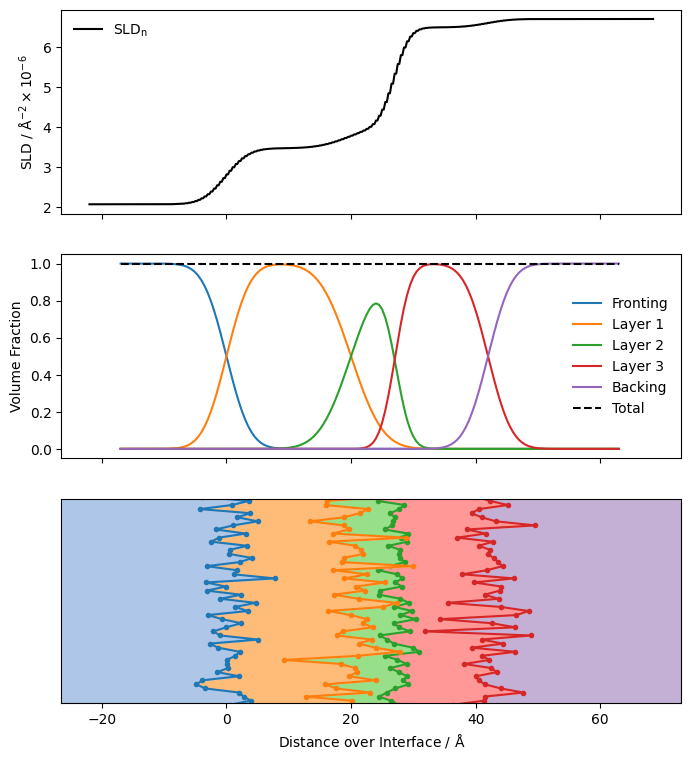

In [92]:
dd_d2o_vfp.plot()

In [96]:
# the fake surface excess is:

from vfp.calc import integrate_vfp, init_demag

red_vfp, red_demag_vfp, idx, demag_arr = init_demag(
    dd_d2o_vfp.tup_demag_locs,
    dd_d2o_vfp.tup_demag_widths,
    dd_d2o_vfp.tup_mslds,
    dd_d2o_vfp.zeds,
    dd_d2o_vfp._arrtotuple(dd_d2o_vfp.vfp),
)

integrals = integrate_vfp(
    dd_d2o_vfp.zeds,
    dd_d2o_vfp.indices,
    dd_d2o_vfp._arrtotuple(red_vfp),
    tuple([2, 3])
)

surf_tail_vf = (
    surf_inner_vf
    * ((surf_head_sld * 3.064*1E-3) / (0.145*1E-3 * surf_tail_sld)) 
    * (integrals[0] / integrals[1])
)

print(f'Inner surf surface excess = {(surf_inner_vf * ((surf_head_sld * 1E-6) / (0.145*1E-3) * periodictable.constants.avogadro_number) * integrals[0]) / 1E20:.3e} mol m-2')
print(f'Outer surf surface excess = {(surf_tail_vf * ((surf_tail_sld * 1E-6) / (3.064*1E-3) * periodictable.constants.avogadro_number) * integrals[1]) / 1E20:.3e} mol m-2')

Inner surf surface excess = 3.427e+01 mol m-2
Outer surf surface excess = 3.427e+01 mol m-2


In [97]:
import matplotlib.pyplot as plt

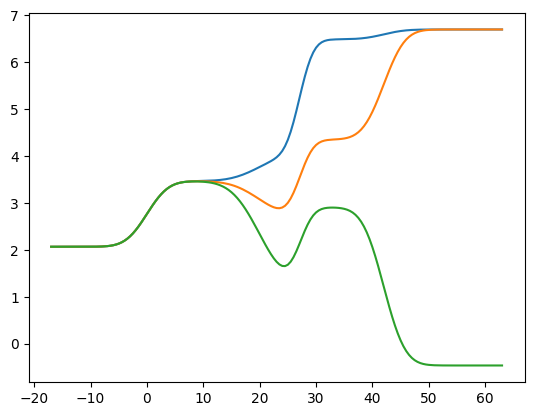

In [98]:
plt.plot(dd_d2o_vfp.z_and_sld()[0],
         dd_d2o_vfp.z_and_sld()[1][0])

plt.plot(dd_h2o_vfp.z_and_sld()[0],
         dd_h2o_vfp.z_and_sld()[1][0])

plt.plot(hd_d2o_vfp.z_and_sld()[0],
         hd_d2o_vfp.z_and_sld()[1][0])

In [99]:
dd_d2o_vfp_refnx = dd_d2o_vfp.transform('refnx')
hd_d2o_vfp_refnx = hd_d2o_vfp.transform('refnx')
dd_h2o_vfp_refnx = dd_h2o_vfp.transform('refnx')

In [100]:
dd_d2o_vfp_struc = SLD(Si_sld, "Si") | dd_d2o_vfp_refnx | SLD(ddod_sld, "ddod")
dd_h2o_vfp_struc = SLD(Si_sld, "Si") | dd_h2o_vfp_refnx | SLD(ddod_sld, "ddod")
hd_d2o_vfp_struc = SLD(Si_sld, "Si") | hd_d2o_vfp_refnx | SLD(hdod_sld, "hdod")

In [101]:
dd_d2o_model = ReflectModel(structure=dd_d2o_vfp_struc, scale=0.99, bkg=1e-6, dq=3*2.355)
dd_h2o_model = ReflectModel(structure=dd_h2o_vfp_struc, scale=1.02, bkg=2e-6, dq=3*2.355)
hd_d2o_model = ReflectModel(structure=hd_d2o_vfp_struc, scale=0.97, bkg=5e-6, dq=3*2.355)

In [102]:
q = np.geomspace(9E-3, 0.3, 110)

dd_d2o_y, dd_d2o_yerr = dd_d2o_model.model(q) + np.random.normal(loc=0, scale=dd_d2o_model.model(q)*0.1, size=110), dd_d2o_model.model(q)*0.1
dd_h2o_y, dd_h2o_yerr = dd_h2o_model.model(q) + np.random.normal(loc=0, scale=dd_h2o_model.model(q)*0.1, size=110), dd_h2o_model.model(q)*0.1
hd_d2o_y, hd_d2o_yerr = hd_d2o_model.model(q) + np.random.normal(loc=0, scale=hd_d2o_model.model(q)*0.1, size=110), hd_d2o_model.model(q)*0.1

In [103]:
dd_d2o_data = ReflectDataset(data=np.vstack((q, dd_d2o_y, dd_d2o_yerr)))
dd_h2o_data = ReflectDataset(data=np.vstack((q, dd_h2o_y, dd_h2o_yerr)))
hd_d2o_data = ReflectDataset(data=np.vstack((q, hd_d2o_y, hd_d2o_yerr)))

## Now we have the fake data lets try to recover the surface excess of the surfactant.

In [104]:
Si = SLD(2.07, name='Si')
SiO2 = SLD(3.47, name='SiO2')
surf_head = SLD(0.26, name='surf_head')
surf_tail = SLD(5.65, name='surf_tail')
d2o = SLD(6.37, name='d2o')
h2o = SLD(-0.54, name='h2o')

hdod = SLD(-0.46, name='hdod')
ddod = SLD(6.7, name='ddod')

## Parameterisation

We can parameterise the inner layer so that the sum of volume fractions must be 1.

In [105]:
sio2_thickness = Parameter(20, name='sio2_thickness', vary=True, bounds=(10, 30))
inner_thickness = Parameter(5, name='inner_thickness', vary=True, bounds=(1, 7))
outer_thickness = Parameter(10, name='outer_thickness', vary=True, bounds=(8, 20))

si_sio2_roughness = Parameter(1, name='si_sio2_roughness', vary=True, bounds=(1, 5))
sio2_inner_roughness = Parameter(1, name='sio2_inner_roughness', vary=True, bounds=(1, 6))
inner_outer_roughness = Parameter(1, name='inner_outer_roughness', vary=True, bounds=(1, 5))
outer_solv_roughness = Parameter(1, name='outer_solv_roughness', vary=True, bounds=(1, 6))

surf_inner_vf = Parameter(0.5, name='surf_inner_vf', vary=True, bounds=(0, 1))
solv_inner_vf = Parameter(0.4, name='solv_inner_vf', vary=True, bounds=(0, 1))

solv_outer_vf = Parameter(0.5, name='solv_outer_vf', vary=True, bounds=(0, 1))

In [106]:
thicknesses = (0, sio2_thickness, inner_thickness, outer_thickness)
roughnesses = (si_sio2_roughness, sio2_inner_roughness, inner_outer_roughness, outer_solv_roughness)

dd_h2o_slds = [Si.real,
               SiO2.real,
               solv_inner_vf*ddod.real + (1-solv_inner_vf) * (surf_inner_vf * surf_head.real + (1-surf_inner_vf) * h2o.real),
               1, # this will be updated by the vfp.
               ddod.real]

dd_d2o_slds = [Si.real,
               SiO2.real,
               solv_inner_vf*ddod.real + (1-solv_inner_vf) * (surf_inner_vf * surf_head.real + (1-surf_inner_vf) * d2o.real),
               1, # this will be updated by the vfp.
               ddod.real]

hd_d2o_slds = [Si.real,
               SiO2.real,
               solv_inner_vf*hdod.real + (1-solv_inner_vf) * (surf_inner_vf * surf_head.real + (1-surf_inner_vf) * d2o.real),
               1, # this will be updated by the vfp.
               hdod.real]

In [108]:
class SLDConstraint:
    """
    Class with two methods that are used by the VFP.
    `layer_choices` returns the indices of the layers that we'll constrain together.
    '__call__' Uses the  a function that   
    """
    def __init__(self, required_pars: dict[float]):
        self.required_pars = required_pars
        
    def layer_choices(self) -> list[int]:
        return [2, 3]
        
    def __call__(self, layer_integrals: list[float]) -> tuple[int, float]:
        lay2_int, lay3_int = layer_integrals
        
        surf_inner_vf, solv_inner_vf, solv_outer_vf, surf_head_sld, surf_tail_sld, solv_sld, water_sld = map(
            self.required_pars.get,
            ['surf_inner_vf', 
             'solv_inner_vf', 
             'solv_outer_vf', 
             'surf_head_sld', 
             'surf_tail_sld', 
             'solv_sld', 
             'water_sld'
             ]
        )
        
        b_surf_head, b_surf_tail = 0.145*1E-3, 3.064*1E-3
        # using the integrals, constrain the volume fraction of the tail
        surf_tail_vf = (
            (surf_inner_vf * (1-solv_inner_vf))
            * ((surf_head_sld * b_surf_tail) / (b_surf_head * surf_tail_sld)) 
            * (lay2_int / lay3_int)
        )
        
        outer_water_vf = 1 - (surf_tail_vf + solv_outer_vf)
        
        # now we have outer_water_vf, we can calculate the true sld of the outer layer:
        layer_idx = 3 # outer layer sld index
        altered_sld = (
            outer_water_vf*water_sld
            + solv_outer_vf*solv_sld
            + surf_tail_vf*surf_tail_sld
        )
        
        return layer_idx, altered_sld

In [109]:
dd_h2o_constraint_ps = dict(
    surf_inner_vf=surf_inner_vf,
    solv_inner_vf=solv_inner_vf,
    solv_outer_vf=solv_outer_vf,
    surf_head_sld=surf_head.real,
    surf_tail_sld=surf_tail.real,
    solv_sld=ddod.real, 
    water_sld=h2o.real,
)

dd_d2o_constraint_ps = dict(
    surf_inner_vf=surf_inner_vf,
    solv_inner_vf=solv_inner_vf,
    solv_outer_vf=solv_outer_vf,
    surf_head_sld=surf_head.real,
    surf_tail_sld=surf_tail.real,
    solv_sld=ddod.real, 
    water_sld=d2o.real,
)

hd_d2o_constraint_ps = dict(
    surf_inner_vf=surf_inner_vf,
    solv_inner_vf=solv_inner_vf,
    solv_outer_vf=solv_outer_vf,
    surf_head_sld=surf_head.real,
    surf_tail_sld=surf_tail.real,
    solv_sld=hdod.real, 
    water_sld=d2o.real,
)

In [110]:
dd_h2o_sld_constraint = SLDConstraint(required_pars=dd_h2o_constraint_ps)
dd_d2o_sld_constraint = SLDConstraint(required_pars=dd_d2o_constraint_ps)
hd_d2o_sld_constraint = SLDConstraint(required_pars=hd_d2o_constraint_ps)

In [111]:
dd_h2o_vfp = vfp.refnxVFP(nslds=dd_h2o_slds,
                          thicknesses=thicknesses,
                          roughnesses=roughnesses,
                          sld_constraint=dd_h2o_sld_constraint)

dd_d2o_vfp = vfp.refnxVFP(nslds=dd_d2o_slds,
                          thicknesses=thicknesses,
                          roughnesses=roughnesses,
                          sld_constraint=dd_d2o_sld_constraint)

hd_d2o_vfp = vfp.refnxVFP(nslds=hd_d2o_slds,
                          thicknesses=thicknesses,
                          roughnesses=roughnesses,
                          sld_constraint=hd_d2o_sld_constraint)

In [112]:
dd_d2o_vfp_struc = Si | dd_d2o_vfp | ddod
dd_h2o_vfp_struc = Si | dd_h2o_vfp | ddod
hd_d2o_vfp_struc = Si | hd_d2o_vfp | hdod

In [113]:
dd_d2o_int = Parameter(1, name='dd_d2o_int', vary=True, bounds=(0.9, 1.1))
dd_d2o_bkg = Parameter(1e-6, name='dd_d2o_bkg', vary=True, bounds=(1e-7, 1e-4))

dd_h2o_int = Parameter(1, name='dd_h2o_int', vary=True, bounds=(0.9, 1.1))
dd_h2o_bkg = Parameter(1e-6, name='dd_h2o_bkg', vary=True, bounds=(1e-7, 1e-4))

hd_d2o_int = Parameter(1, name='hd_d2o_int', vary=True, bounds=(0.9, 1.1))
hd_d2o_bkg = Parameter(1e-6, name='hd_d2o_bkg', vary=True, bounds=(1e-7, 1e-4))

In [114]:
dd_d2o_model = ReflectModel(structure=dd_d2o_vfp_struc, scale=dd_d2o_int, bkg=dd_d2o_bkg, dq=3*2.355)
dd_h2o_model = ReflectModel(structure=dd_h2o_vfp_struc, scale=dd_h2o_int, bkg=dd_h2o_bkg, dq=3*2.355)
hd_d2o_model = ReflectModel(structure=hd_d2o_vfp_struc, scale=hd_d2o_int, bkg=hd_d2o_bkg, dq=3*2.355)

In [115]:
dd_d2o_obj = Objective(model=dd_d2o_model, data=dd_d2o_data)
dd_h2o_obj = Objective(model=dd_h2o_model, data=dd_h2o_data)
hd_d2o_obj = Objective(model=hd_d2o_model, data=hd_d2o_data)
global_objective = GlobalObjective([dd_d2o_obj, dd_h2o_obj, hd_d2o_obj])

In [116]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter: 'dd_d2o_int'  , value=1          , bounds=[0.9, 1.1]>
<Parameter: 'dd_d2o_bkg'  , value=1e-06          , bounds=[1e-07, 0.0001]>
<Parameter:'sio2_thickness', value=20          , bounds=[10.0, 30.0]>
<Parameter:'inner_thickness', value=5          , bounds=[1.0, 7.0]>
<Parameter:'outer_thickness', value=10          , bounds=[8.0, 20.0]>
<Parameter:'si_sio2_roughness', value=1          , bounds=[1.0, 5.0]>
<Parameter:'sio2_inner_roughness', value=1          , bounds=[1.0, 6.0]>
<Parameter:'inner_outer_roughness', value=1          , bounds=[1.0, 5.0]>
<Parameter:'outer_solv_roughness', value=1          , bounds=[1.0, 6.0]>
<Parameter:'solv_inner_vf', value=0.4          , bounds=[0.0, 1.0]>
<Parameter:'surf_inner_vf', value=0.5          , bounds=[0.0, 1.0]>
<Parameter:'solv_outer_vf', value=0.5          , bounds=[0.0, 1.0]>
<Parameter: 'dd_h2o_int'  , value=1          , b

## Fit the objective.

Differential evolution uses multiprocessing to parallelise the fit procedure. Unfortunately, the combination of windows + jupyter notebook doesn't make this easy. One way around is to define SLDConstraint class in a separate file and import here, but this doesn't really lend it self to an example! Another way around this is to use the `pathos` package in place of multiprocessing with `ProcessPool`. This can be installed via pip.

In [117]:
from pathos.pools import ProcessPool

pool = ProcessPool(nodes=4)
fitter = CurveFitter(objective=global_objective)
fitter.fit(method='differential_evolution', workers=pool.map)

# if not running on windows, just run the following:
# fitter = CurveFitter(objective=global_objective)
# fitter.fit(method='differential_evolution', workers=-1)

0it [00:00, ?it/s]c:\Users\sandy\OneDrive\PDRA - Job 2021-2024\VFP\.venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
-2872.218281346422: : 53it [10:06, 11.45s/it] 


             message: Optimization terminated successfully.
             success: True
                 fun: -2878.867253807248
                   x: [ 9.992e-01  8.687e-07 ...  9.934e-01  5.165e-06]
                 nit: 53
                nfev: 14303
          population: [[ 1.002e+00  8.959e-07 ...  9.902e-01  5.342e-06]
                       [ 1.009e+00  5.935e-07 ...  1.030e+00  4.379e-06]
                       ...
                       [ 9.604e-01  8.664e-07 ...  9.879e-01  5.374e-06]
                       [ 9.737e-01  1.122e-06 ...  9.907e-01  4.647e-06]]
 population_energies: [-2.879e+03 -2.791e+03 ... -2.862e+03 -2.824e+03]
                 jac: [ 1.267e+02  1.414e+04 ... -4.336e+01 -1.242e+04]
               covar: [[ 1.917e-04 -4.688e-10 ...  2.929e-05  1.070e-09]
                       [-4.688e-10  6.784e-14 ... -2.198e-09 -6.880e-14]
                       ...
                       [ 2.929e-05 -2.198e-09 ...  3.968e-04  1.390e-09]
                       [ 1.070e-09 -6

In [118]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter: 'dd_d2o_int'  , value=0.999218 +/- 0.0138, bounds=[0.9, 1.1]>
<Parameter: 'dd_d2o_bkg'  , value=8.68663e-07 +/- 2.6e-07, bounds=[1e-07, 0.0001]>
<Parameter:'sio2_thickness', value=19.3973 +/- 3.16 , bounds=[10.0, 30.0]>
<Parameter:'inner_thickness', value=4.73353 +/- 13.1 , bounds=[1.0, 7.0]>
<Parameter:'outer_thickness', value=17.8129 +/- 15.7 , bounds=[8.0, 20.0]>
<Parameter:'si_sio2_roughness', value=1.67997 +/- 6.14 , bounds=[1.0, 5.0]>
<Parameter:'sio2_inner_roughness', value=3.41453 +/- 4.62 , bounds=[1.0, 6.0]>
<Parameter:'inner_outer_roughness', value=3.82974 +/- 13.3 , bounds=[1.0, 5.0]>
<Parameter:'outer_solv_roughness', value=3.44057 +/- 3.05 , bounds=[1.0, 6.0]>
<Parameter:'solv_inner_vf', value=0.290756 +/- 0.822, bounds=[0.0, 1.0]>
<Parameter:'surf_inner_vf', value=0.856078  +/- 1.1 , bounds=[0.0, 1.0]>
<Parameter:'solv_outer_vf', value=0.512166 +/- 0.0

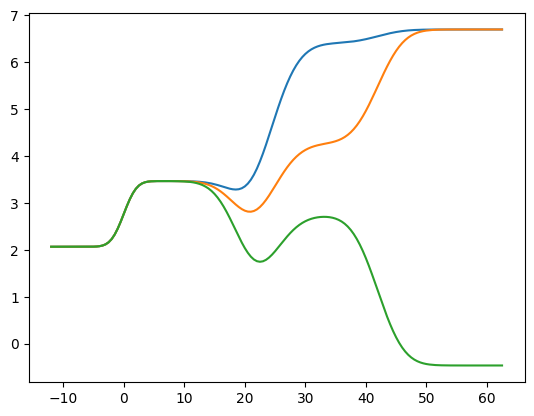

In [119]:
plt.plot(dd_d2o_vfp.z_and_sld()[0],
         dd_d2o_vfp.z_and_sld()[1][0])

plt.plot(dd_h2o_vfp.z_and_sld()[0],
         dd_h2o_vfp.z_and_sld()[1][0])

plt.plot(hd_d2o_vfp.z_and_sld()[0],
         hd_d2o_vfp.z_and_sld()[1][0])

## Check we reasonably recover surface excess

In [123]:
# the fake surface excess is:

from vfp.calc import integrate_vfp, init_demag

red_vfp, red_demag_vfp, idx, demag_arr = init_demag(
    dd_d2o_vfp.tup_demag_locs,
    dd_d2o_vfp.tup_demag_widths,
    dd_d2o_vfp.tup_mslds,
    dd_d2o_vfp.zeds,
    dd_d2o_vfp._arrtotuple(dd_d2o_vfp.vfp),
)

integrals = integrate_vfp(
    dd_d2o_vfp.zeds,
    dd_d2o_vfp.indices,
    dd_d2o_vfp._arrtotuple(red_vfp),
    tuple([2, 3])
)

surf_tail_vf = float(
    surf_inner_vf * (1-solv_inner_vf)
    * ((surf_head_sld * 3.064*1E-3) / (0.145*1E-3 * surf_tail_sld)) 
    * (integrals[0] / integrals[1])
)

print(f'Inner surf surface excess = {float((surf_inner_vf * (1-solv_inner_vf) * ((surf_head_sld * 1E-6) / (0.145*1E-3) * periodictable.constants.avogadro_number) * integrals[0])) / 1E20:.3e} mol m-2')
print(f'Outer surf surface excess = {(surf_tail_vf * ((surf_tail_sld * 1E-6) / (3.064*1E-3) * periodictable.constants.avogadro_number) * integrals[1]) / 1E20:.3e} mol m-2')

Inner surf surface excess = 3.823e+01 mol m-2
Outer surf surface excess = 3.823e+01 mol m-2
